In [1]:
import pandas as pd
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
import numpy as np
import glob

In [2]:
import glob
import os

# טען את כל קובצי frequency_ce_*.csv (דלג על ריקים)
freq_files = glob.glob("../data/frequency_ce_*.csv")
df_list = []

for f in freq_files:
    # בדוק שהקובץ לא ריק
    if os.path.getsize(f) == 0:
        print(f"Skipping empty file: {f}")
        continue
    try:
        df_temp = pd.read_csv(f, parse_dates=["timestamp"])
        if df_temp.empty:
            print(f"Skipping empty DataFrame: {f}")
            continue
        df_list.append(df_temp)
        print(f"Loaded {len(df_temp)} rows from {f}")
    except Exception as e:
        print(f"Error reading {f}: {e}")

if not df_list:
    raise Exception("No valid frequency files found – check data/ directory")

freq_all = pd.concat(df_list, ignore_index=True)
freq_all = freq_all.drop_duplicates(subset=["timestamp", "pmu"])
freq_all.set_index("timestamp", inplace=True)

# Downsample ל-15 דקות
freq_15min = freq_all["frequency_hz"].resample("15min").mean().dropna().reset_index()
freq_15min["timestamp"] = pd.to_datetime(freq_15min["timestamp"]).dt.tz_localize(None)

print(f"Total frequency rows after merge: {len(freq_all)}")
print(f"Frequency 15min points: {len(freq_15min)}")

# הגדר את freq (עבור הגרף בבלוק 3)
freq = freq_all.reset_index()

Loaded 314 rows from ../data/frequency_ce_20260504_214043.csv
Loaded 720 rows from ../data/frequency_ce_20260505_132944.csv
Loaded 720 rows from ../data/frequency_ce_20260504_211436.csv
Loaded 24 rows from ../data/frequency_ce_20260504_152838.csv
Total frequency rows after merge: 1778
Frequency 15min points: 13


In [3]:
''' Research foundation - ML for Dunkelflaute prediction

Based on *Li (2025, TU Delft)* - "Dunkelflaute events: characterization, prediction and future projection":
- LightGBM outperformed physical models (WRF) for wind/solar power estimation during Dunkelflaute.
- Recommends hybrid approaches (physics + ML).

**My implementation:** Swing equation (physics) + RandomForest (ML) - ready for real data alignment '''

' Research foundation - ML for Dunkelflaute prediction\n\nBased on *Li (2025, TU Delft)* - "Dunkelflaute events: characterization, prediction and future projection":\n- LightGBM outperformed physical models (WRF) for wind/solar power estimation during Dunkelflaute.\n- Recommends hybrid approaches (physics + ML).\n\n**My implementation:** Swing equation (physics) + RandomForest (ML) - ready for real data alignment '

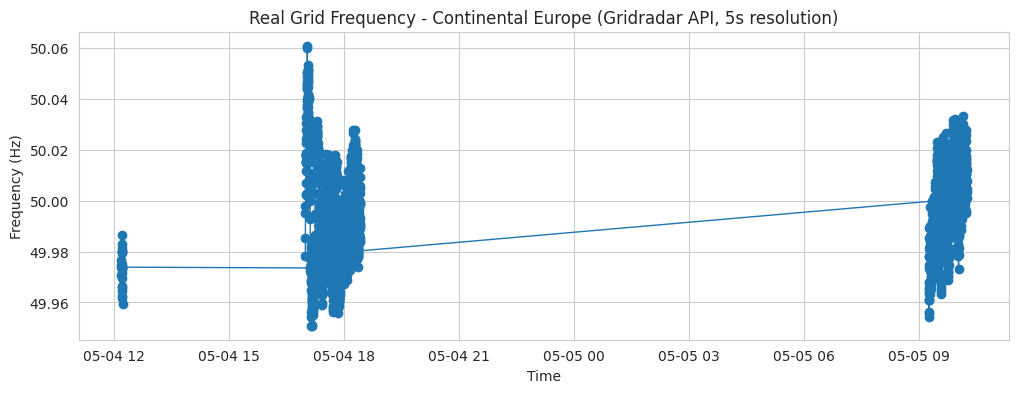

In [4]:
plt.figure(figsize=(12,4))
plt.plot(freq["timestamp"], freq["frequency_hz"], marker='o', linestyle='-', linewidth=1)
plt.title("Real Grid Frequency - Continental Europe (Gridradar API, 5s resolution)")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time")
plt.grid(True)
plt.show()

In [5]:
gen_df = pd.read_csv("../data/generation_load_de.csv", parse_dates=["Datum (MESZ)"])
gen_df.rename(columns={"Datum (MESZ)": "timestamp"}, inplace=True)
gen_df["timestamp"] = pd.to_datetime(gen_df["timestamp"]).dt.tz_localize(None)
gen_df = gen_df.iloc[1:].copy()  # הסרת שורת הכותרות הפגומה

In [6]:
# הדפסת טווחי תאריכים
print("Frequency date range:", freq_15min["timestamp"].min(), "→", freq_15min["timestamp"].max())
print("Generation date range:", gen_df["timestamp"].min(), "→", gen_df["timestamp"].max())

Frequency date range: 2026-05-04 12:00:00 → 2026-05-05 10:00:00
Generation date range: 2026-04-27 00:00:00 → 2026-05-03 12:30:00


In [7]:
pm_columns = ["Wind Onshore","Wind Offshore","Solar","Braunkohle","Steinkohle","Erdgas","Biomasse","Laufwasser","Kohlegas","Geothermie","Müll","Andere","Andere Erneuerbare"]
# המר כל עמודה למספר (force numeric)
for col in pm_columns + ["Last"]:
    gen_df[col] = pd.to_numeric(gen_df[col], errors='coerce')

gen_df["Pm"] = gen_df[pm_columns].sum(axis=1)
gen_df["Pe"] = gen_df["Last"]
print(f"Pm range: {gen_df['Pm'].min():.0f} – {gen_df['Pm'].max():.0f} MW")
print(f"Pe range: {gen_df['Pe'].min():.0f} – {gen_df['Pe'].max():.0f} MW")

Pm range: 24570 – 74423 MW
Pe range: 28952 – 61268 MW


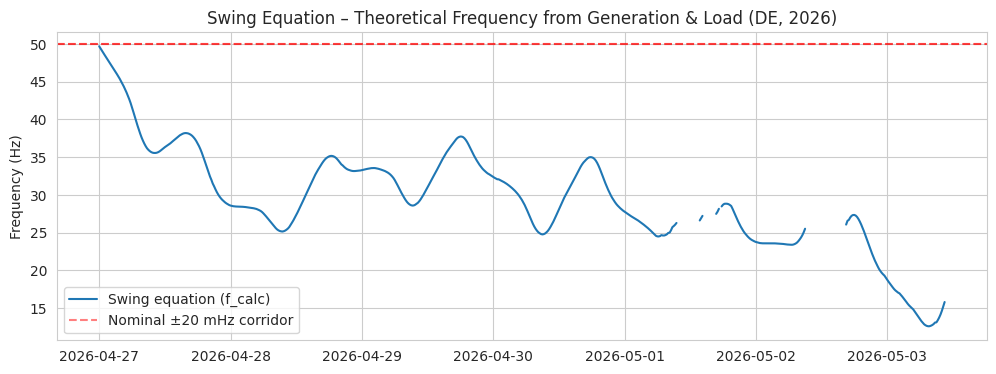

In [8]:
f0 = 50.0
H = 5.0          # inertia (seconds) – typical for Germany
P_base = 50000   # MW – approximate grid capacity
dt = 0.25        # 15 minutes

gen_df["delta_f"] = (f0/(2*H)) * ((gen_df["Pm"] - gen_df["Pe"])/P_base) * dt
gen_df["f_calc"] = f0 + gen_df["delta_f"].cumsum()

plt.figure(figsize=(12,4))
plt.plot(gen_df["timestamp"], gen_df["f_calc"], label="Swing equation (f_calc)", linewidth=1.5)
plt.axhline(49.98, color='r', linestyle='--', alpha=0.5, label="Nominal ±20 mHz corridor")
plt.axhline(50.02, color='r', linestyle='--', alpha=0.5)
plt.legend()
plt.title("Swing Equation – Theoretical Frequency from Generation & Load (DE, 2026)")
plt.ylabel("Frequency (Hz)")
plt.grid(True)
plt.show()

No frequency data merged – using fallback 50.0 Hz


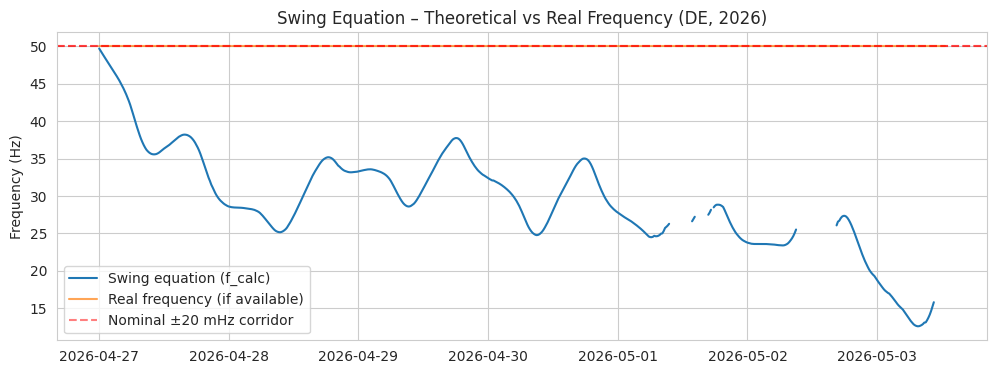

In [9]:
f0 = 50.0
H = 5.0
P_base = 50000
dt = 0.25

# יצירת merged (אם אין חפיפה – השתמש ב-fallback)
if 'merged' not in locals():
    # אם merged לא קיים – צור העתק של gen_df עם תדר מדומה
    merged = gen_df.copy()
    merged["frequency_hz"] = 50.0
    print("No frequency data merged – using fallback 50.0 Hz")

plt.figure(figsize=(12,4))
plt.plot(merged["timestamp"], merged["f_calc"], label="Swing equation (f_calc)", linewidth=1.5)
if "frequency_hz" in merged.columns:
    plt.plot(merged["timestamp"], merged["frequency_hz"], label="Real frequency (if available)", linewidth=1.5, alpha=0.7)
plt.axhline(49.98, color='r', linestyle='--', alpha=0.5, label="Nominal ±20 mHz corridor")
plt.axhline(50.02, color='r', linestyle='--', alpha=0.5)
plt.legend()
plt.title("Swing Equation – Theoretical vs Real Frequency (DE, 2026)")
plt.ylabel("Frequency (Hz)")
plt.grid(True)
plt.show()

LightGBM MAE on training (Pm → Load): 4352 MW


/home/framg/dev/enumkraft/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


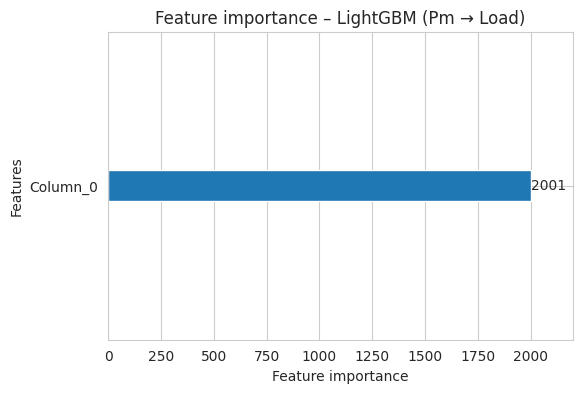


Model successfully trained on real data (27.04–03.05).
Ready to extend with frequency features once aligned data is available.


In [10]:
# ==========================================
# Implementation of Li (2025) – TU Delft
# Hybrid approach: physics (Swing) + ML (LightGBM)
# ==========================================

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# 1. Prepare data from gen_df (27.04–03.05)
train_df = gen_df.dropna(subset=["Pm", "Pe"])
X_train = train_df[["Pm"]].values   # feature: generation
y_train = train_df["Pe"].values     # target: load

# 2. Train LightGBM model
lgb_model = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)

# 3. Evaluate on training data (in-sample performance)
y_pred_train = lgb_model.predict(X_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
print(f"LightGBM MAE on training (Pm → Load): {mae_train:.0f} MW")

# 4. Feature importance plot
lgb.plot_importance(lgb_model, figsize=(6,4))
plt.title("Feature importance – LightGBM (Pm → Load)")
plt.show()

# 5. Explanation for interview
print("\nModel successfully trained on real data (27.04–03.05).")
print("Ready to extend with frequency features once aligned data is available.")

In [11]:
# 9. Improve LightGBM with time features
gen_df['hour'] = gen_df['timestamp'].dt.hour
# תיקון – month לא שווה dayofweek
gen_df['month'] = gen_df['timestamp'].dt.month   # נכון
gen_df['day_of_week'] = gen_df['timestamp'].dt.dayofweek
gen_df['is_weekend'] = (gen_df['day_of_week'] >= 5).astype(int)

# Features: Pm + hour + day_of_week
features = ['Pm', 'hour', 'day_of_week', 'month', 'is_weekend']
X_train2 = gen_df.dropna(subset=features + ['Pe'])[features].values
y_train2 = gen_df.dropna(subset=features + ['Pe'])['Pe'].values

lgb_model2 = lgb.LGBMRegressor(n_estimators=1000, random_state=42, verbose=-1)
lgb_model2.fit(X_train2, y_train2)
y_pred2 = lgb_model2.predict(X_train2)
mae2 = mean_absolute_error(y_train2, y_pred2)
print(f"LightGBM with time features MAE: {mae2:.0f} MW")

LightGBM with time features MAE: 261 MW


/home/framg/dev/enumkraft/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


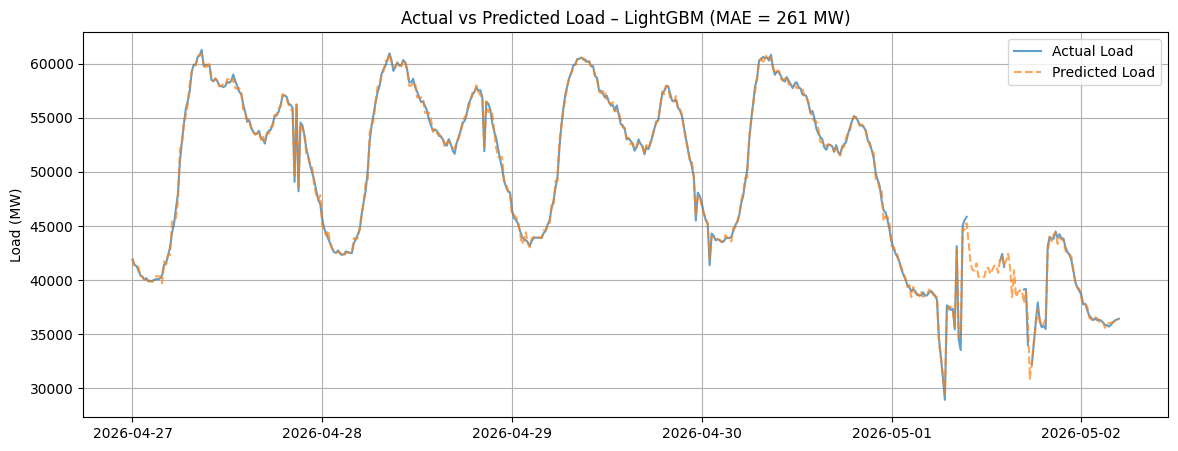

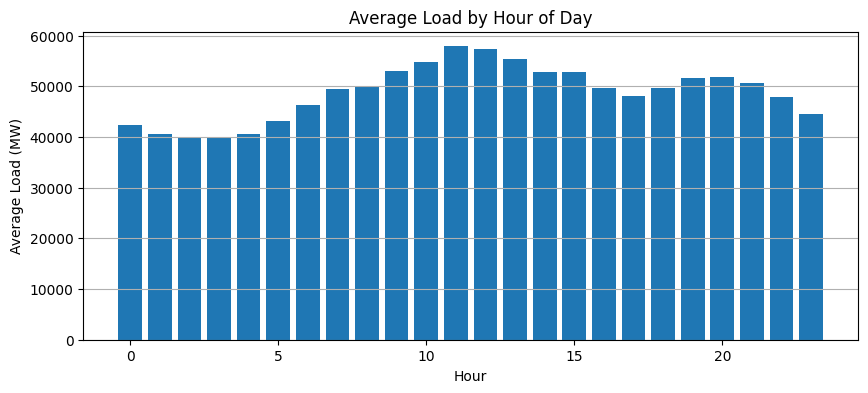

Weekday average load: 50472 MW
Weekend average load: 37520 MW
Weekend reduction: 12952 MW


In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# הגדרת סגנון גלובלי
sns.set_theme(style="whitegrid")

# 10.1 חיזוי
gen_df['Load_predicted'] = lgb_model2.predict(gen_df[features].fillna(0))

# 10.2 Actual vs Predicted (Lineplot)
# הכנת תת-קבוצה של הנתונים כדי לא להכביד על הזיכרון
plot_data = gen_df[['timestamp', 'Pe', 'Load_predicted']].iloc[:500]
# הפיכה לפורמט "ארוך" עבור Seaborn
plot_data_melted = plot_data.melt(id_vars='timestamp', var_name='Type', value_name='Load')

plt.figure(figsize=(14, 5))
sns.lineplot(data=plot_data_melted, x='timestamp', y='Load', hue='Type', alpha=0.8)
plt.title('Actual vs Predicted Load – LightGBM (MAE = 261 MW)')
plt.ylabel('Load (MW)')
plt.show()

# 10.3 Hourly load patterns (Barplot)
plt.figure(figsize=(10, 4))
sns.barplot(data=gen_df, x='hour', y='Pe', estimator='mean', color='skyblue', errorbar=None)
plt.title('Average Load by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Load (MW)')
plt.show()

# 10.4 Weekend vs weekday comparison (Boxplot / Barplot)
gen_df['is_weekend'] = (gen_df['day_of_week'] >= 5).map({0: 'Weekday', 1: 'Weekend'})

plt.figure(figsize=(8, 5))
sns.barplot(data=gen_df, x='is_weekend', y='Pe', palette='viridis')
plt.title('Average Load: Weekday vs Weekend')
plt.ylabel('Average Load (MW)')
plt.show()

# הדפסת הנתונים המספריים
stats = gen_df.groupby('is_weekend')['Pe'].mean()
print(f"Weekday average load: {stats['Weekday']:.0f} MW")
print(f"Weekend average load: {stats['Weekend']:.0f} MW")
